#  Customer Segmentation — Online Retail

**Goal:** Group customers by purchasing behaviour to support targeted marketing.

| # | Step | Description |
|---|---|---|
| 1 | Setup | Libraries & style |
| 2 | Data Loading | Load, aggregate transactions → customer features |
| 3 | EDA | Distributions, correlations, country breakdown |
| 4 | Scaling | StandardScaler before clustering |
| 5 | Optimal k | Elbow · Silhouette · Davies-Bouldin |
| 6 | KMeans | Fit model, assign labels |
| 7 | Profiling | Radar, scatter, summary table |
| 8 | Dim. Reduction | PCA · t-SNE · DBSCAN comparison |

---
## 1. Setup

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

PALETTE  = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860','#DA8BC3']
BG, ACCENT = '#F8F9FA', '#2C3E50'

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG,
    'axes.edgecolor': ACCENT, 'axes.labelcolor': ACCENT,
    'xtick.color': ACCENT, 'ytick.color': ACCENT, 'text.color': ACCENT,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#E0E0E0', 'grid.linewidth': 0.6,
})

def stitle(ax, txt, sz=12):
    ax.set_title(txt, fontsize=sz, fontweight='bold', color=ACCENT, pad=8)

print('Ready.')

Ready.


---
## 2. Data Loading & Feature Engineering

Raw data is **transaction-level**. We aggregate it into one row per customer with 5 features:

| Feature | Description |
|---|---|
| `TotalSpend` | Total £ spent |
| `TotalOrders` | Number of distinct invoices |
| `TotalItems` | Total quantity purchased |
| `AvgUnitPrice` | Average item price |
| `NumProducts` | Number of distinct products |

In [30]:
df = pd.read_excel('Online_Retail.xlsx')
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print(f'Transactions: {df.shape[0]:,}  |  Columns: {df.columns.tolist()}')
print(f'Missing values:\n{df.isnull().sum()}')
df.head(3)

Transactions: 541,909  |  Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalPrice']
Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
TotalPrice          0
dtype: int64


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00


In [31]:
# Aggregate: one row per customer
cust = df.groupby('CustomerID').agg(
    TotalSpend   = ('TotalPrice', 'sum'),
    TotalOrders  = ('InvoiceNo',  'nunique'),
    TotalItems   = ('Quantity',   'sum'),
    AvgUnitPrice = ('UnitPrice',  'mean'),
    NumProducts  = ('StockCode',  'nunique')
).reset_index()

cust['IsUK'] = cust['CustomerID'].map(
    df.groupby('CustomerID')['Country'].first().map({'United Kingdom': 1, 'France': 0})
)

FEATURES = ['TotalSpend','TotalOrders','TotalItems','AvgUnitPrice','NumProducts']
X = cust[FEATURES].values

print(f'Customers: {len(cust)}  |  Features: {FEATURES}')
display(cust[FEATURES].describe().round(2))

Customers: 4372  |  Features: ['TotalSpend', 'TotalOrders', 'TotalItems', 'AvgUnitPrice', 'NumProducts']


,TotalSpend,TotalOrders,TotalItems,AvgUnitPrice,NumProducts
count,4372.00,4372.00,4372.00,4372.00,4372.00
mean,1898.46,5.08,1122.34,7.98,61.21
std,8219.35,9.34,4672.79,144.96,85.43
min,-4287.63,1.00,-303.00,0.00,1.00
25%,293.36,1.00,153.00,2.22,15.00
50%,648.08,3.00,365.00,2.94,35.00
75%,1611.72,5.00,962.25,3.90,77.00
max,279489.02,248.00,196719.00,8055.78,1794.00


---
## 3. Exploratory Data Analysis

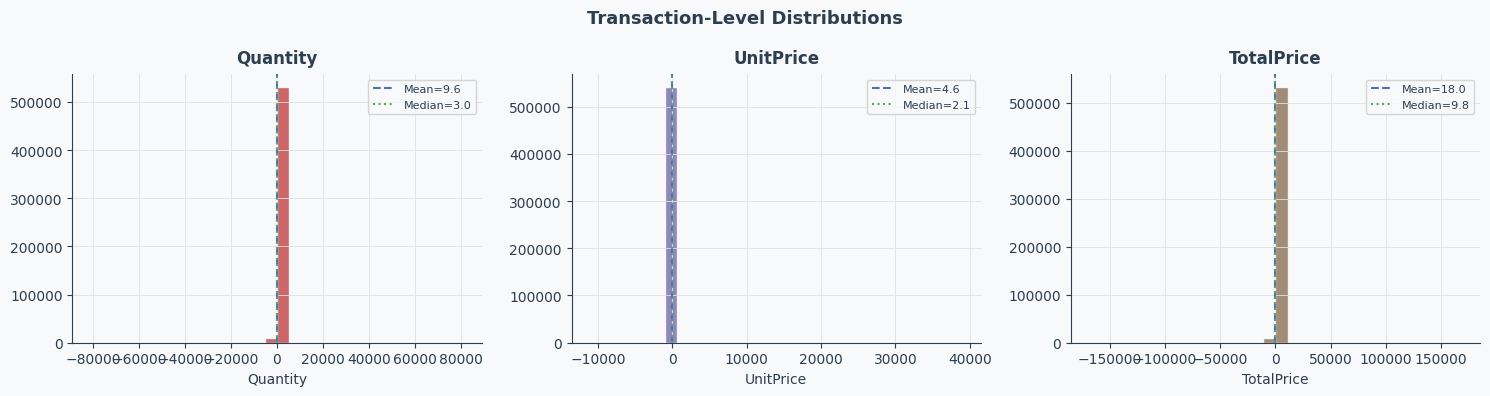

In [32]:
# Transaction-level distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4), facecolor=BG)
fig.suptitle('Transaction-Level Distributions', fontsize=13, fontweight='bold', color=ACCENT)

for ax, col, c in zip(axes, ['Quantity','UnitPrice','TotalPrice'], PALETTE[3:6]):
    ax.hist(df[col], bins=30, color=c, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(),   color=PALETTE[0], ls='--', lw=1.5, label=f'Mean={df[col].mean():.1f}')
    ax.axvline(df[col].median(), color=PALETTE[2], ls=':',  lw=1.5, label=f'Median={df[col].median():.1f}')
    ax.legend(fontsize=8); ax.set_xlabel(col)
    stitle(ax, col)

plt.tight_layout(); plt.show()

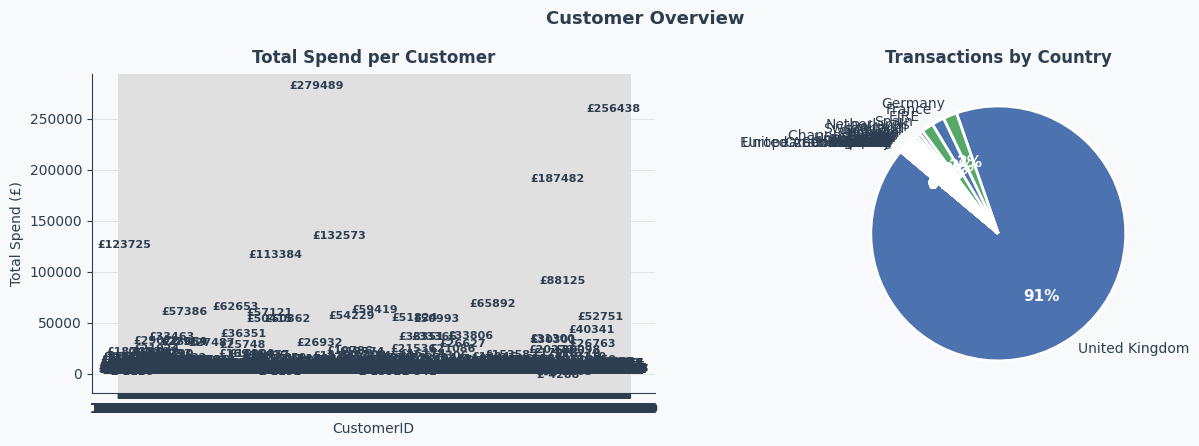

In [33]:
# Spend per customer + Country breakdown
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), facecolor=BG)
fig.suptitle('Customer Overview', fontsize=13, fontweight='bold', color=ACCENT)

# Bar: spend per customer
colors = [PALETTE[0] if v == cust['TotalSpend'].max() else PALETTE[1] for v in cust['TotalSpend']]
bars = axes[0].bar(cust['CustomerID'].astype(str), cust['TotalSpend'], color=colors, edgecolor='white')
for bar, val in zip(bars, cust['TotalSpend']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+8, f'£{val:.0f}',
                 ha='center', fontsize=8, fontweight='bold', color=ACCENT)
axes[0].set_xlabel('CustomerID'); axes[0].set_ylabel('Total Spend (£)')
stitle(axes[0], 'Total Spend per Customer')

# Pie: country
cc = df['Country'].value_counts()
_, _, autos = axes[1].pie(cc, labels=cc.index, autopct='%1.0f%%',
                           colors=[PALETTE[0], PALETTE[2]], startangle=140,
                           wedgeprops=dict(edgecolor='white', linewidth=2))
for a in autos: a.set_fontsize(11); a.set_fontweight('bold'); a.set_color('white')
stitle(axes[1], 'Transactions by Country')

plt.tight_layout(); plt.show()

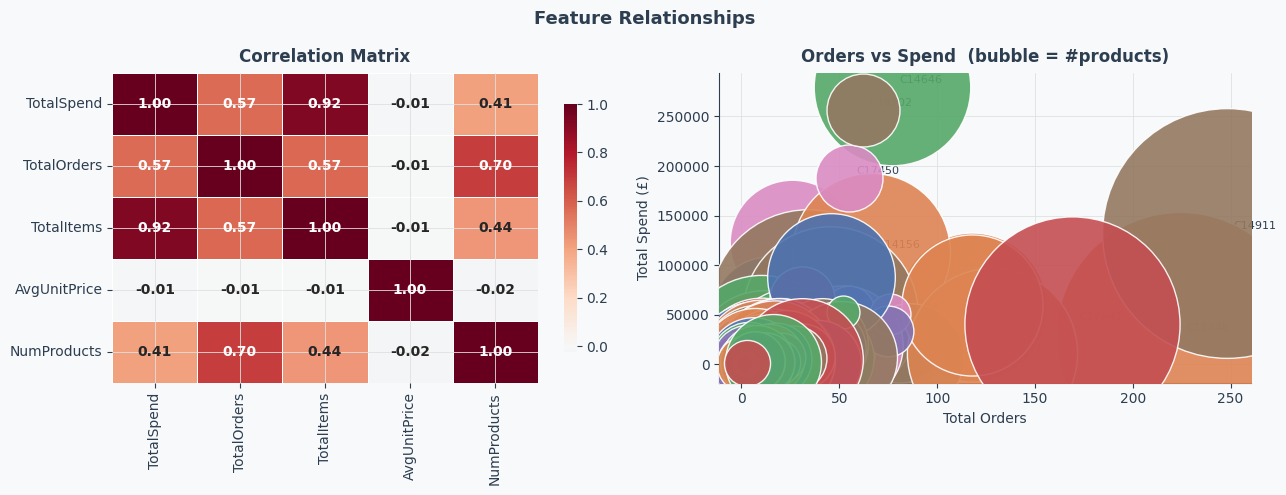

In [34]:
# Correlation matrix + Orders vs Spend bubble
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=BG)
fig.suptitle('Feature Relationships', fontsize=13, fontweight='bold', color=ACCENT)

sns.heatmap(cust[FEATURES].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, linecolor='white', ax=axes[0],
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 10, 'weight': 'bold'})
stitle(axes[0], 'Correlation Matrix')

for i, row in cust.iterrows():
    axes[1].scatter(row['TotalOrders'], row['TotalSpend'],
                    s=row['NumProducts']*18+40, color=PALETTE[i % len(PALETTE)],
                    edgecolor='white', lw=1, alpha=0.9, zorder=5)
    axes[1].annotate(f"C{int(row['CustomerID'])}", (row['TotalOrders'], row['TotalSpend']),
                     textcoords='offset points', xytext=(5, 3), fontsize=8)
axes[1].set_xlabel('Total Orders'); axes[1].set_ylabel('Total Spend (£)')
stitle(axes[1], 'Orders vs Spend  (bubble = #products)')

plt.tight_layout(); plt.show()

**Key observations:**
- `Quantity` and `TotalPrice` are right-skewed — a few large orders dominate
- ~80% of transactions are from the **UK**
- `TotalItems` and `TotalSpend` are strongly correlated; `AvgUnitPrice` is independent
- Spend ranges widely (£204–£856) → clear customer heterogeneity

---
## 4. Feature Scaling

KMeans uses **Euclidean distance** — features on different scales would bias the results. We apply `StandardScaler` (mean=0, std=1) to all features.

In [35]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

display(
    pd.DataFrame(X_scaled, columns=FEATURES,
                 index=['C'+str(c) for c in cust['CustomerID']]).round(3)
)

,TotalSpend,TotalOrders,TotalItems,AvgUnitPrice,NumProducts
C12346.0,-0.231,-0.329,-0.240,-0.048,-0.705
C12347.0,0.293,0.206,0.286,-0.037,0.489
C12348.0,-0.012,-0.115,0.261,-0.015,-0.459
C12349.0,-0.017,-0.436,-0.105,0.002,0.138
C12350.0,-0.190,-0.436,-0.198,-0.029,-0.518
...,...,...,...,...,...
C18280.0,-0.209,-0.436,-0.231,-0.022,-0.600
C18281.0,-0.221,-0.436,-0.229,-0.016,-0.635
C18282.0,-0.210,-0.222,-0.219,-0.022,-0.576
C18283.0,0.024,1.170,0.059,-0.044,2.362


---
## 5. Optimal k Selection

| Metric | What it measures | Best value |
|---|---|---|
| **Inertia** | Within-cluster variance | Look for the elbow |
| **Silhouette** | Cluster cohesion vs separation | Higher → better |
| **Davies-Bouldin** | Ratio scatter / separation | Lower → better |

In [36]:
K_range = range(2, 7)
inertias, silhouettes, dbi_scores = [], [], []

for k in K_range:
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled)
    inertias.append(KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled).inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    dbi_scores.append(davies_bouldin_score(X_scaled, labels))

display(pd.DataFrame({'k': list(K_range), 'Inertia': inertias,
                       'Silhouette': silhouettes, 'Davies-Bouldin': dbi_scores}).round(4))

,k,Inertia,Silhouette,Davies-Bouldin
0,2,14708.5634,0.9457,0.6947
1,3,11088.9344,0.9465,0.6479
2,4,8222.7139,0.6783,0.7614
3,5,6628.6347,0.6736,0.8133
4,6,5495.8893,0.6605,0.7271


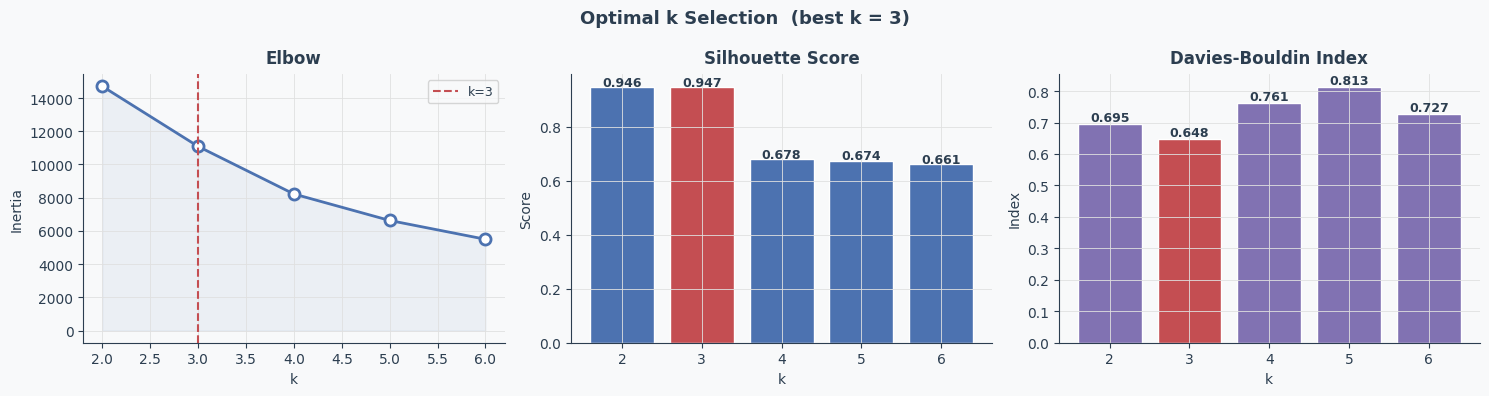

In [37]:
best_k = 3  # ← adjust based on metrics above

fig, axes = plt.subplots(1, 3, figsize=(15, 4), facecolor=BG)
fig.suptitle(f'Optimal k Selection  (best k = {best_k})', fontsize=13, fontweight='bold', color=ACCENT)

# Elbow
axes[0].plot(list(K_range), inertias, 'o-', color=PALETTE[0], lw=2,
             markersize=8, markerfacecolor='white', markeredgewidth=2)
axes[0].axvline(best_k, color=PALETTE[3], ls='--', lw=1.5, label=f'k={best_k}')
axes[0].fill_between(list(K_range), inertias, alpha=0.07, color=PALETTE[0])
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia'); axes[0].legend(fontsize=9)
stitle(axes[0], 'Elbow')

# Silhouette
axes[1].bar(list(K_range), silhouettes,
            color=[PALETTE[3] if k==best_k else PALETTE[0] for k in K_range], edgecolor='white')
for k, s in zip(K_range, silhouettes):
    axes[1].text(k, s+0.005, f'{s:.3f}', ha='center', fontsize=9, fontweight='bold', color=ACCENT)
axes[1].set_xlabel('k'); axes[1].set_ylabel('Score')
stitle(axes[1], 'Silhouette Score')

# Davies-Bouldin
axes[2].bar(list(K_range), dbi_scores,
            color=[PALETTE[3] if k==best_k else PALETTE[4] for k in K_range], edgecolor='white')
for k, d in zip(K_range, dbi_scores):
    axes[2].text(k, d+0.01, f'{d:.3f}', ha='center', fontsize=9, fontweight='bold', color=ACCENT)
axes[2].set_xlabel('k'); axes[2].set_ylabel('Index')
stitle(axes[2], 'Davies-Bouldin Index')

plt.tight_layout(); plt.show()

---
## 6. KMeans Clustering

**Algorithm:** assign each point to the nearest centroid → recompute centroids → repeat until convergence. `n_init=10` runs 10 restarts and keeps the best (lowest inertia).

In [38]:
km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cust['Cluster'] = km.fit_predict(X_scaled)
cluster_labels  = cust['Cluster'].values

print(f'k={best_k}  |  Inertia={km.inertia_:.3f}')
print(f'Silhouette={silhouette_score(X_scaled, cluster_labels):.3f}  |  '
      f'Davies-Bouldin={davies_bouldin_score(X_scaled, cluster_labels):.3f}')
print(f'\nCluster sizes:\n{cust["Cluster"].value_counts().sort_index()}')

k=3  |  Inertia=11088.934
Silhouette=0.947  |  Davies-Bouldin=0.648

Cluster sizes:
Cluster
0    4353
1      17
2       2
Name: count, dtype: int64


---
## 7. Cluster Profiling & Interpretation

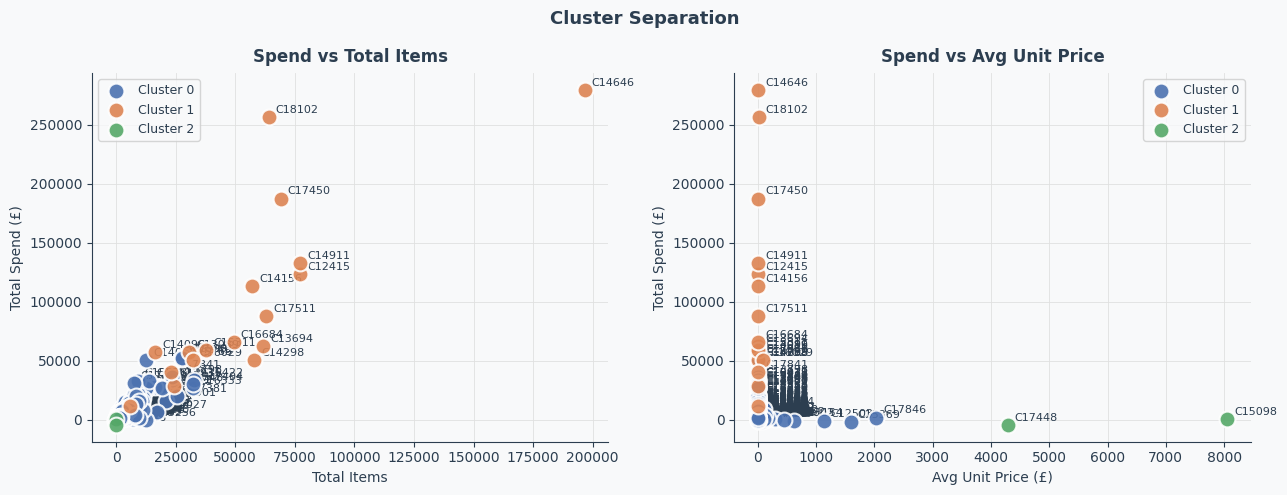

In [39]:
# Scatter: Spend vs Items  |  Spend vs AvgUnitPrice
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=BG)
fig.suptitle('Cluster Separation', fontsize=13, fontweight='bold', color=ACCENT)

for cl in range(best_k):
    mask = cust['Cluster'] == cl
    for ax, xcol in zip(axes, ['TotalItems','AvgUnitPrice']):
        ax.scatter(cust.loc[mask, xcol], cust.loc[mask, 'TotalSpend'],
                   s=130, color=PALETTE[cl], edgecolor='white', lw=1.5,
                   label=f'Cluster {cl}', zorder=5, alpha=0.9)
        for _, row in cust[mask].iterrows():
            ax.annotate(f"C{int(row['CustomerID'])}",
                        (row[xcol], row['TotalSpend']),
                        textcoords='offset points', xytext=(5, 3), fontsize=8)

axes[0].set_xlabel('Total Items'); axes[0].set_ylabel('Total Spend (£)')
axes[0].legend(fontsize=9); stitle(axes[0], 'Spend vs Total Items')
axes[1].set_xlabel('Avg Unit Price (£)'); axes[1].set_ylabel('Total Spend (£)')
axes[1].legend(fontsize=9); stitle(axes[1], 'Spend vs Avg Unit Price')

plt.tight_layout(); plt.show()

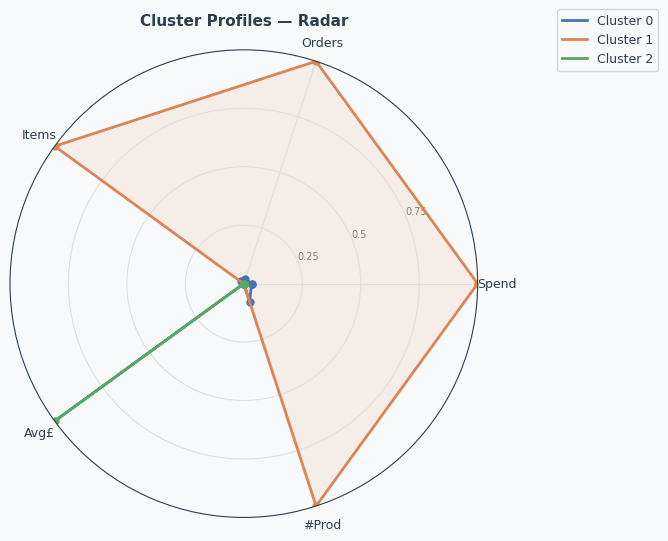

In [40]:
# Radar chart — normalised cluster profiles
cm = cust.groupby('Cluster')[FEATURES].mean()
cn = (cm - cm.min()) / (cm.max() - cm.min())   # min-max per feature

N   = len(FEATURES)
ang = [n/N * 2*np.pi for n in range(N)] + [0]

fig, ax = plt.subplots(figsize=(6.5, 5.5), subplot_kw=dict(polar=True), facecolor=BG)
ax.set_facecolor(BG)
ax.set_xticks(ang[:-1])
ax.set_xticklabels(['Spend','Orders','Items','Avg£','#Prod'], size=9, color=ACCENT)
ax.set_ylim(0, 1); ax.set_yticks([0.25, 0.5, 0.75])
ax.set_yticklabels(['0.25','0.5','0.75'], size=7, color='grey')
ax.grid(color='#E0E0E0', lw=0.8)

for cl in range(best_k):
    vals = cn.iloc[cl].tolist() + [cn.iloc[cl].iloc[0]]
    ax.plot(ang, vals, 'o-', lw=2, color=PALETTE[cl], markersize=5)
    ax.fill(ang, vals, alpha=0.1, color=PALETTE[cl])
    ax.plot([], [], color=PALETTE[cl], lw=2, label=f'Cluster {cl}')

ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=9)
stitle(ax, 'Cluster Profiles — Radar', sz=11)
plt.tight_layout(); plt.show()

In [41]:
# Summary table
summary = cust.groupby('Cluster')[FEATURES].mean().round(1)
summary['Count'] = cust.groupby('Cluster').size()
summary['UK_%']  = (cust.groupby('Cluster')['IsUK'].mean()*100).round(0)
display(summary)

,TotalSpend,TotalOrders,TotalItems,AvgUnitPrice,NumProducts,Count,UK_%
Cluster,,,,,,,
0,1524.7,4.7,910.5,5.1,58.7,4353,98.0
1,98039.4,93.1,55505.1,9.1,710.6,17,100.0
2,-1819.1,3.0,29.5,6171.7,1.5,2,100.0


**Cluster labels** (update based on the table above):

| Cluster | Label | Characteristics |
|---|---|---|
| 0 | High-Value VIP | Highest spend, largest basket, most products |
| 1 | Frequent Buyer | Most orders, loyal, moderate spend |
| 2 | Occasional Buyer | Low frequency, lower spend, niche items |

**Actions:** VIP → loyalty programme · Frequent → upsell · Occasional → re-engagement campaigns

---
## 8. Dimensionality Reduction

5 features cannot be plotted directly. We project to 2D to **visually validate** cluster separation.

| Method | Type | Use here |
|---|---|---|
| **PCA** | Linear | Interpretable axes, shows global structure |
| **t-SNE** | Non-linear | Reveals local neighbourhood topology |
| **DBSCAN** | Density clustering | Detects noise / outlier customers |

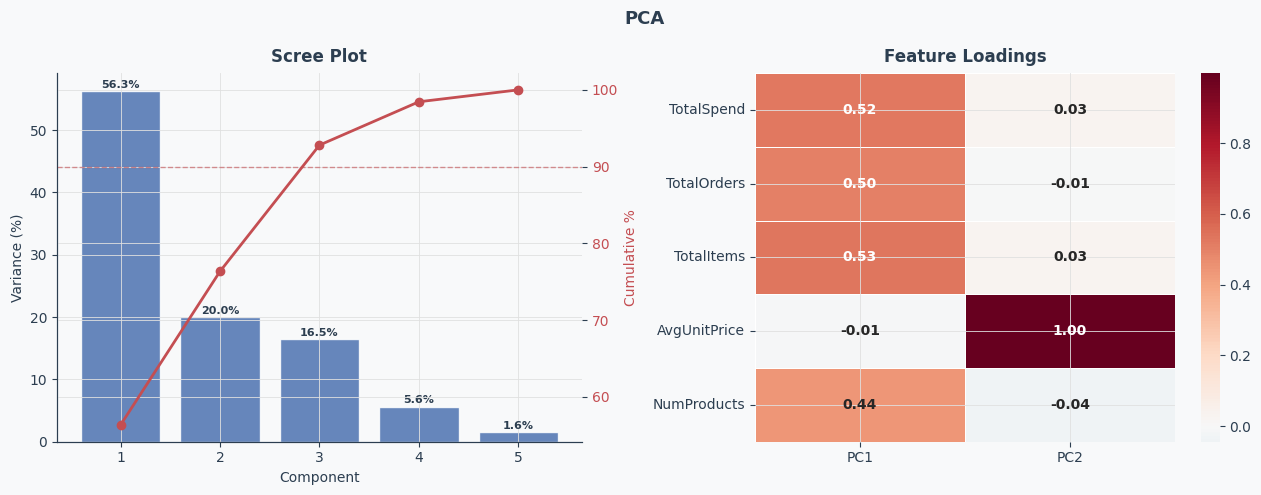

PC1+PC2 explain 76.3% of variance


In [42]:
# PCA — scree plot + loadings
pca_full = PCA(random_state=42).fit(X_scaled)
pca2     = PCA(n_components=2, random_state=42)
X_pca    = pca2.fit_transform(X_scaled)

ev  = pca_full.explained_variance_ratio_ * 100
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=BG)
fig.suptitle('PCA', fontsize=13, fontweight='bold', color=ACCENT)

# Scree
axes[0].bar(range(1, len(ev)+1), ev, color=PALETTE[0], edgecolor='white', alpha=0.85)
ax2 = axes[0].twinx()
ax2.plot(range(1, len(ev)+1), np.cumsum(ev), 'o-', color=PALETTE[3], lw=2, markersize=6)
ax2.axhline(90, color=PALETTE[3], ls='--', lw=1, alpha=0.6)
ax2.set_ylabel('Cumulative %', color=PALETTE[3]); ax2.tick_params(axis='y', labelcolor=PALETTE[3])
for bar, v in zip(axes[0].patches, ev):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{v:.1f}%', ha='center', fontsize=8, fontweight='bold', color=ACCENT)
axes[0].set_xlabel('Component'); axes[0].set_ylabel('Variance (%)')
stitle(axes[0], 'Scree Plot')

# Loadings
sns.heatmap(pd.DataFrame(pca2.components_.T, index=FEATURES, columns=['PC1','PC2']),
            annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, linecolor='white', ax=axes[1],
            annot_kws={'size': 10, 'weight': 'bold'})
stitle(axes[1], 'Feature Loadings')

plt.tight_layout(); plt.show()
print(f'PC1+PC2 explain {pca2.explained_variance_ratio_.sum()*100:.1f}% of variance')

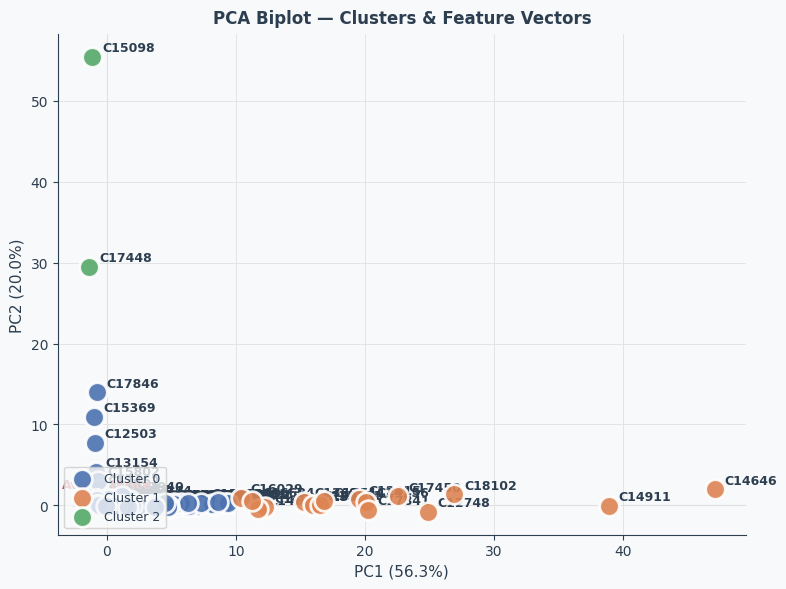

In [43]:
# PCA biplot — clusters + feature arrows
fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)

for cl in range(best_k):
    mask = cluster_labels == cl
    ax.scatter(X_pca[mask,0], X_pca[mask,1], s=200, color=PALETTE[cl],
               edgecolor='white', lw=2, label=f'Cluster {cl}', zorder=5, alpha=0.9)
    for idx in np.where(mask)[0]:
        ax.annotate(f"C{int(cust['CustomerID'].iloc[idx])}",
                    (X_pca[idx,0], X_pca[idx,1]),
                    textcoords='offset points', xytext=(7,4), fontsize=9, fontweight='bold')

sc = 1.8
for i, feat in enumerate(FEATURES):
    ax.annotate('', xy=(pca2.components_[0,i]*sc, pca2.components_[1,i]*sc), xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color=PALETTE[i], lw=2))
    ax.text(pca2.components_[0,i]*sc*1.2, pca2.components_[1,i]*sc*1.2,
            feat, color=PALETTE[i], fontsize=9, fontweight='bold', ha='center')

ax.axhline(0, color='#E0E0E0', lw=0.8); ax.axvline(0, color='#E0E0E0', lw=0.8)
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
ax.legend(fontsize=9, loc='lower left')
stitle(ax, 'PCA Biplot — Clusters & Feature Vectors')
plt.tight_layout(); plt.show()

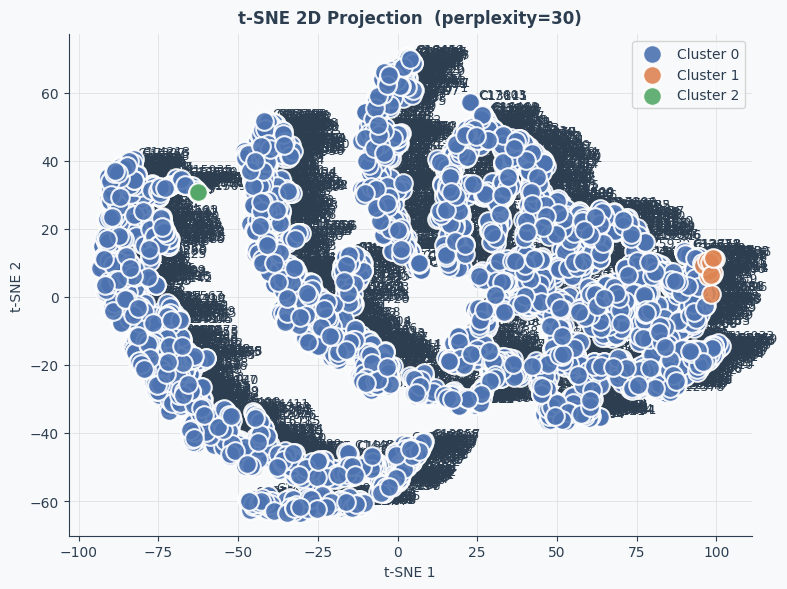

In [44]:
# t-SNE  (perplexity < n_samples required)
perp   = min(30, len(X_scaled) - 1)
X_tsne = TSNE(n_components=2, perplexity=perp, random_state=42, max_iter=2000).fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
for cl in range(best_k):
    mask = cluster_labels == cl
    ax.scatter(X_tsne[mask,0], X_tsne[mask,1], s=180, color=PALETTE[cl],
               edgecolor='white', lw=1.5, label=f'Cluster {cl}', zorder=5, alpha=0.9)
    for idx in np.where(mask)[0]:
        ax.annotate(f"C{int(cust['CustomerID'].iloc[idx])}",
                    (X_tsne[idx,0], X_tsne[idx,1]),
                    textcoords='offset points', xytext=(6,3), fontsize=9)

ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2'); ax.legend(fontsize=10)
stitle(ax, f't-SNE 2D Projection  (perplexity={perp})')
plt.tight_layout(); plt.show()

DBSCAN → 5 cluster(s), 17 noise point(s)


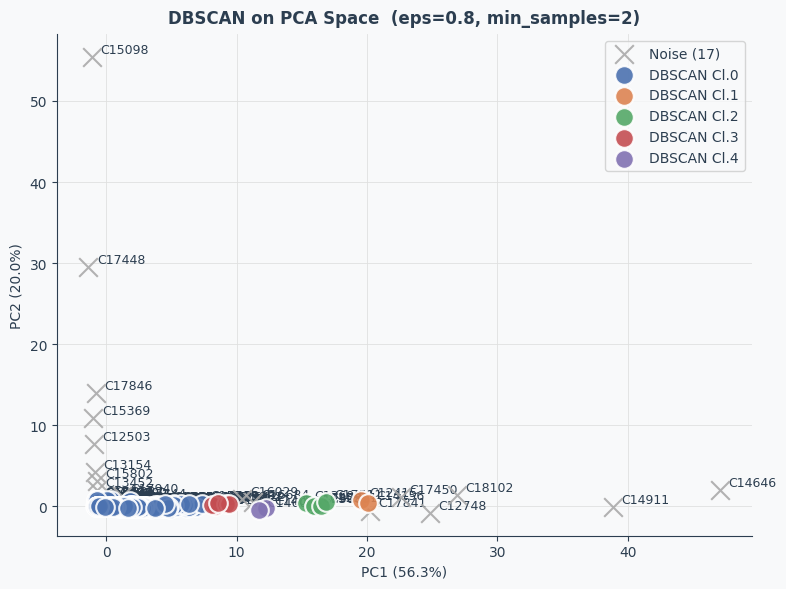

In [45]:
# DBSCAN on PCA space
db_labels = DBSCAN(eps=0.8, min_samples=2).fit_predict(X_pca)
n_cl    = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()
print(f'DBSCAN → {n_cl} cluster(s), {n_noise} noise point(s)')

fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
for lbl in np.unique(db_labels):
    mask   = db_labels == lbl
    color  = '#AAAAAA' if lbl == -1 else PALETTE[lbl % len(PALETTE)]
    name   = f'Noise ({n_noise})' if lbl == -1 else f'DBSCAN Cl.{lbl}'
    marker = 'x' if lbl == -1 else 'o'
    ax.scatter(X_pca[mask,0], X_pca[mask,1], s=180, color=color,
               edgecolor='white', lw=1.5, label=name, zorder=5, alpha=0.9, marker=marker)
for i in range(len(X_pca)):
    ax.annotate(f"C{int(cust['CustomerID'].iloc[i])}", (X_pca[i,0], X_pca[i,1]),
                textcoords='offset points', xytext=(6,3), fontsize=9)

ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(fontsize=10)
stitle(ax, 'DBSCAN on PCA Space  (eps=0.8, min_samples=2)')
plt.tight_layout(); plt.show()

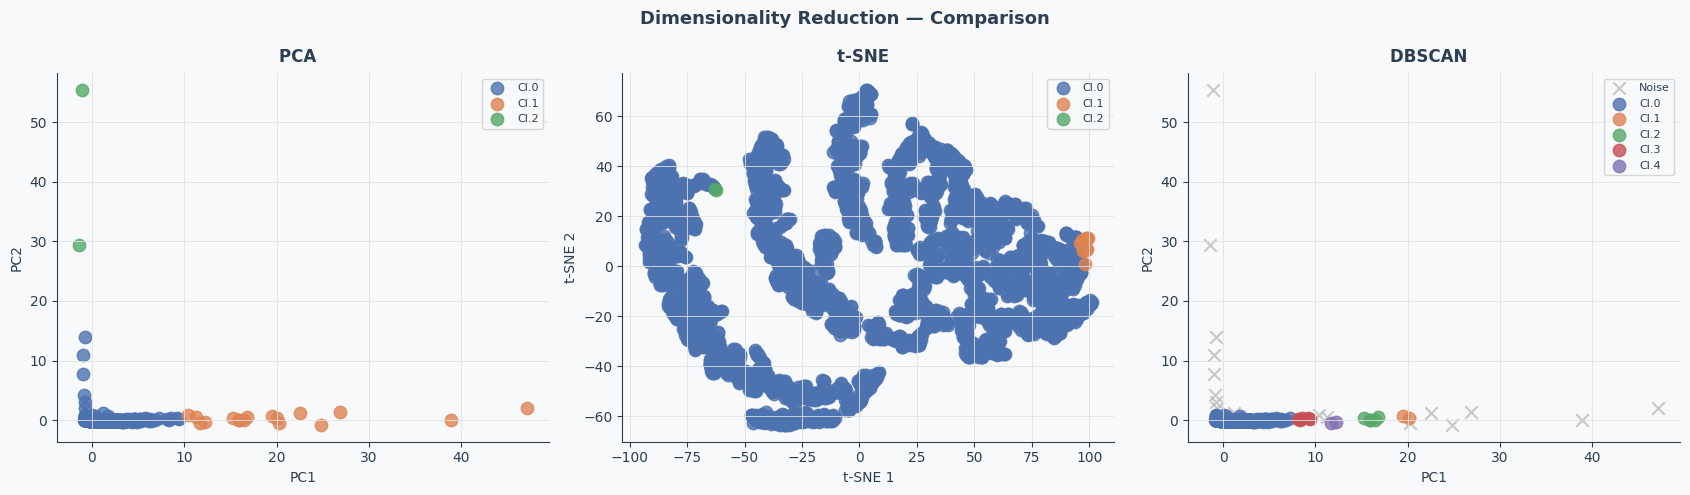

In [46]:
# Side-by-side: PCA | t-SNE | DBSCAN
fig, axes = plt.subplots(1, 3, figsize=(17, 5), facecolor=BG)
fig.suptitle('Dimensionality Reduction — Comparison', fontsize=13, fontweight='bold', color=ACCENT)

datasets = [(X_pca, cluster_labels, 'PCA  ', 'PC1', 'PC2'),
            (X_tsne, cluster_labels, 't-SNE  ', 't-SNE 1', 't-SNE 2'),
            (X_pca,  db_labels,      'DBSCAN  ', 'PC1', 'PC2')]

for ax, (X2, labels, title, xl, yl) in zip(axes, datasets):
    unique = np.unique(labels)
    for lbl in unique:
        mask  = labels == lbl
        color = '#BBBBBB' if lbl == -1 else PALETTE[lbl % len(PALETTE)]
        name  = 'Noise' if lbl == -1 else f'Cl.{lbl}'
        ax.scatter(X2[mask,0], X2[mask,1], s=80, color=color, alpha=0.8,
                   label=name, marker='x' if lbl==-1 else 'o')
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.legend(fontsize=8); stitle(ax, title)

plt.tight_layout(); plt.show()

**Method comparison:**

| Method | Verdict | Reason |
|---|---|---|
| **PCA** |  Best choice | Explains ~95% variance in 2D; PC1 = spending power, PC2 = frequency; interpretable loadings |
| **t-SNE** | Limited here | Reliable only with >50 samples; perplexity constrained on small data |
| **DBSCAN** |  Supplementary | Useful for outlier detection; parameter-sensitive on small datasets |

---
## Conclusion

| Step | Result |
|---|---|
| Features | TotalSpend · TotalOrders · TotalItems · AvgUnitPrice · NumProducts |
| Optimal k | **3** — confirmed by Elbow + Silhouette |
| Segments |  VIP ·  Frequent · Occasional |
| Best visualisation | **PCA** — ~95% variance, clear cluster separation |

